In [1]:
from datetime import datetime

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns
import shapely

from wpp import data, db
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = db.connect()
state_fips = '12'

In [3]:
# Create poi bg distance lookup table
table_name = f"bg_poi_dist_{state_fips}"
con.execute(f"""
    CREATE TABLE IF NOT EXISTS {table_name} AS
    SELECT DISTINCT
        bgpv.ID_STORE,
        bgpv.HOME_CBG,
        ST_Distance_Sphere(p.GEOM, ST_Centroid(bg.geom)) AS DIST_METERS
    FROM bg_poi_visits_{state_fips} bgpv
    JOIN pois_{state_fips} p ON bgpv.ID_STORE = p.ID_STORE
    JOIN bg_{state_fips} bg ON bgpv.HOME_CBG = bg.GEOID
""")
con.sql(f"SELECT * FROM {table_name} LIMIT 5")

┌──────────┬──────────────┬────────────────────┐
│ ID_STORE │   HOME_CBG   │    DIST_METERS     │
│ varchar  │   varchar    │       double       │
├──────────┼──────────────┼────────────────────┤
│ 11218081 │ 120310105022 │ 10540.437003477688 │
│ 11218081 │ 120310144251 │  21132.32057681407 │
│ 811003   │ 120860090403 │ 3627.7206267164747 │
│ 811003   │ 120860151021 │ 13682.126489194801 │
│ 811003   │ 120860106093 │  6709.809059019299 │
└──────────┴──────────────┴────────────────────┘

In [18]:
bg_visits = con.sql(f"""
    WITH bg AS (
        SELECT GEOID, COUNTYFP, ST_Centroid(geom) as centroid
        FROM bg_{state_fips}
    ), bg_visits AS (
        SELECT 
            HOME_CBG, POI_CBG,
            DATE_RANGE_START, DATE_RANGE_END,
            SUM(VISITOR_COUNT) AS VISITOR_COUNT 
        FROM bg_poi_visits_{state_fips} 
        GROUP BY 1, 2, 3, 4
    )
    SELECT 
        bgv.*,
        bgh.centroid AS HOME_CBG_CENTROID,
        bgp.centroid AS POI_CBG_CENTROID,
        ST_Distance_Sphere(bgh.centroid, bgp.centroid) AS DIST_METERS,
        bgh.COUNTYFP AS HOME_COUNTY,
        bgp.COUNTYFP AS POI_COUNTY,
    FROM bg_visits bgv
    JOIN bg bgh ON bgv.HOME_CBG = bgh.GEOID
    JOIN bg bgp ON bgv.POI_CBG = bgp.GEOID
""").pl()
bg_visits.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

HOME_CBG,POI_CBG,DATE_RANGE_START,DATE_RANGE_END,VISITOR_COUNT,HOME_CBG_CENTROID,POI_CBG_CENTROID,DIST_METERS,HOME_COUNTY,POI_COUNTY
str,str,datetime[μs],datetime[μs],"decimal[38,0]",binary,binary,f64,str,str
"""121113820082""","""121113820071""",2025-10-06 00:00:00,2025-10-12 00:00:00,1269,"b""\x01\x01\x00\x00\x00;\xbe\xeb\x1e\x99\x17T\xc0\xd6\x11\x97\xf25P;@""","b""\x01\x01\x00\x00\x00\x97'\x10\x92\x85\x16T\xc0\xc5d\xdd\xbc}G;@""",1974.71651,"""111""","""111"""
"""120110606051""","""120110605015""",2025-10-06 00:00:00,2025-10-12 00:00:00,1056,"b""\x01\x01\x00\x00\x00\xa1\x89\xf17\xdd\x10T\xc0\x9b\x08\xcc\xa5P"":@""","b""\x01\x01\x00\x00\x00\x92\xc0\xa4\x95h\x0fT\xc0\x8c0\xaf4\xee$:@""",2536.296238,"""011""","""011"""
"""121319506082""","""121319506091""",2025-10-06 00:00:00,2025-10-12 00:00:00,12295,"b""\x01\x01\x00\x00\x00\xd2\x99:E\xde\x98U\xc0\x8e\x08\xa7x\xc5a>@""","b""\x01\x01\x00\x00\x00\xaek\x03\xd4\xf8\x94U\xc0H^\xe9\xd80^>@""",6770.161508,"""131""","""131"""
"""120950148124""","""120950167411""",2025-10-06 00:00:00,2025-10-12 00:00:00,8781,"b""\x01\x01\x00\x00\x00\xd4\xd4\xf4\xbc\xcd]T\xc0o\xe0RE\xddx<@""","b""\x01\x01\x00\x00\x00\xf2=\x0a[\xe2LT\xc0?Z#7\xc5\x8d<@""",29428.045736,"""095""","""095"""
"""120950148123""","""120950167411""",2025-10-06 00:00:00,2025-10-12 00:00:00,56,"b""\x01\x01\x00\x00\x00\xb1\xd7nFy]T\xc0\xc7\x09\xca\xe1\xb4|<@""","b""\x01\x01\x00\x00\x00\xf2=\x0a[\xe2LT\xc0?Z#7\xc5\x8d<@""",28844.629116,"""095""","""095"""


In [19]:
bg = con.sql(f"""
    SELECT GEOID, COUNTYFP, ST_Centroid(geom) as centroid
    FROM bg_{state_fips}
""").pl()
bg.head()

GEOID,COUNTYFP,centroid
str,str,binary
"""121113822022""","""111""","b""\x01\x01\x00\x00\x00\xa7\x1d\xa0\x09b$T\xc0\xe8j2'og;@"""
"""121113822021""","""111""","b""\x01\x01\x00\x00\x00\xa7\x98\xe7\xf1X#T\xc0\x13s\xecQ\x07L;@"""
"""121113822012""","""111""","b""\x01\x01\x00\x00\x00S\x9a&~\xfd""T\xc0\xb1+~\xbd\xec\x80;@"""
"""121113809023""","""111""","b""\x01\x01\x00\x00\x00t\xc9\x14\x83\x0e\x17T\xc0Z\x0d\xc2\x9b^v;@"""
"""121113802002""","""111""","b""\x01\x01\x00\x00\x00\xe7)\xa6\xee\x96\x15T\xc0\x1c\x9f\xed\xabuv;@"""


In [24]:
agg = bg_visits.group_by("DATE_RANGE_START", "HOME_CBG").agg(
    pl.col("VISITOR_COUNT").sum(),
    ((pl.col("VISITOR_COUNT") * pl.col("DIST_METERS")).sum() / pl.col("VISITOR_COUNT").sum()).alias("DIST_METERS")
)
agg.head()

DATE_RANGE_START,HOME_CBG,VISITOR_COUNT,DIST_METERS
datetime[μs],str,"decimal[38,0]",f64
2025-05-19 00:00:00,"""121030259021""",64435,6922.692952
2025-01-27 00:00:00,"""120990036001""",42449,5583.967425
2025-05-26 00:00:00,"""120559617013""",59514,33744.864773
2025-02-03 00:00:00,"""120990077641""",70966,9416.189199
2025-02-17 00:00:00,"""120860004103""",64847,3424.985904


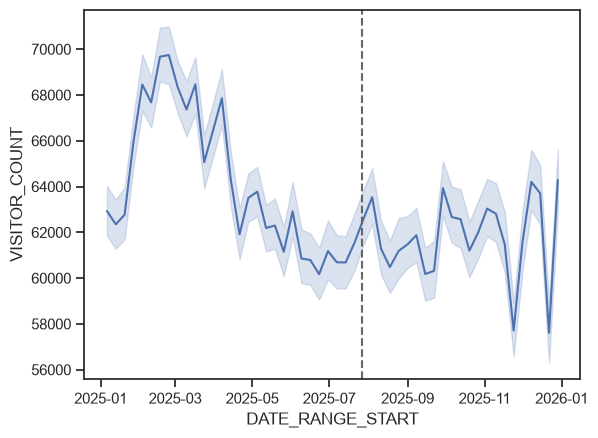

In [25]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="VISITOR_COUNT",
    legend=False
)
heatwave_date = datetime.fromisoformat("2025-07-27")
ax.axvline(heatwave_date, color="#666", linestyle="--")

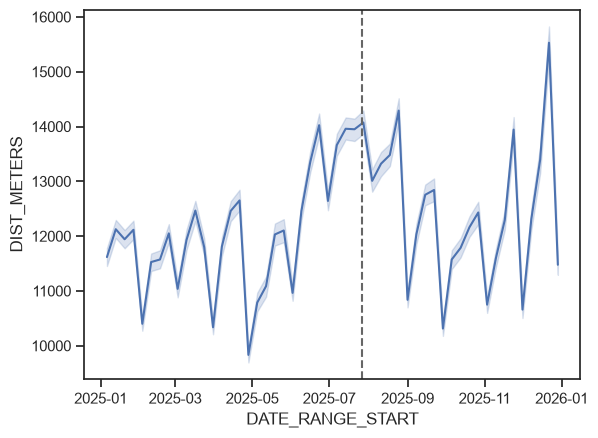

In [26]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="DIST_METERS",
    legend=False
)
heatwave_date = datetime.fromisoformat("2025-07-27")
ax.axvline(heatwave_date, color="#666", linestyle="--")

In [27]:
agg = bg_visits.group_by("DATE_RANGE_START").agg(
    pl.col("VISITOR_COUNT").sum(),
    ((pl.col("VISITOR_COUNT") * pl.col("DIST_METERS")).sum() / pl.col("VISITOR_COUNT").sum()).alias("DIST_METERS")
)
agg.head()

DATE_RANGE_START,VISITOR_COUNT,DIST_METERS
datetime[μs],"decimal[38,0]",f64
2025-04-21 00:00:00,825480561,13076.644315
2025-04-14 00:00:00,857598829,12892.381926
2025-12-08 00:00:00,856236545,12803.565478
2025-08-11 00:00:00,817338697,13718.743887
2025-12-01 00:00:00,821152879,10990.473215


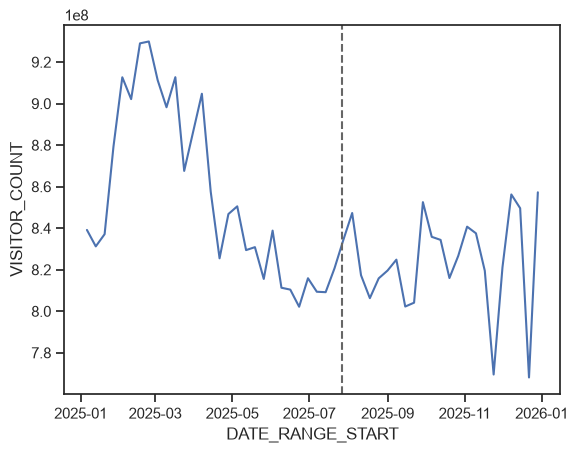

In [28]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="VISITOR_COUNT",
    legend=False
)
heatwave_date = datetime.fromisoformat("2025-07-27")
ax.axvline(heatwave_date, color="#666", linestyle="--")

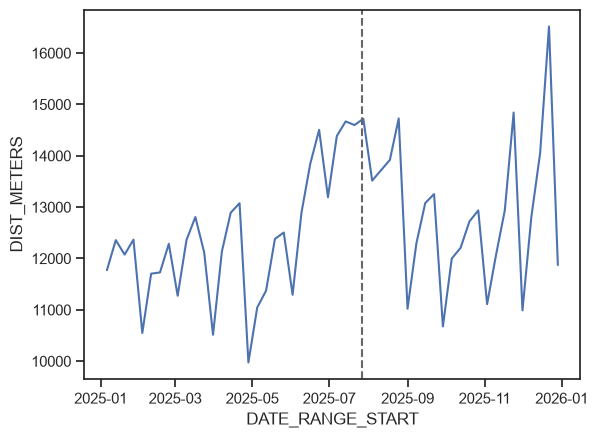

In [29]:
ax = sns.lineplot(
    agg,
    x="DATE_RANGE_START",
    y="DIST_METERS",
    legend=False
)
heatwave_date = datetime.fromisoformat("2025-07-27")
ax.axvline(heatwave_date, color="#666", linestyle="--")